In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite, gammaln

from core.IntensityModes import hermite_gauss as Hg, hermite_gauss_1d as Hg_1d, laguerre_gauss as Lg
from core.Polarization_elements import polarizers,scalar_to_vector, filter_polarizer,q_plate as qp
from core.masks import turbulence_mask as turb
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product as dp
from core.Optical_elements import angular_spectrum as angSpec, tilt, mirror, beam_splitter as bs, lens

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

from tqdm import trange

# Separating modes

In [2]:
x = np.linspace(-1e-2,1e-2,3000)
y = np.linspace(-1e-2,1e-2,3000)
x,y = np.meshgrid(x,y)
z1 =.2
z2=.2

m=10
hg = Hg(x, y, m)
arm1,arm2 = bs(hg)


# Propagating

In [3]:
'''
arm1 = angSpec(arm1, x, y, z=z1)
arm1 = mirror(arm1, x, y)
arm1 = angSpec(arm1, x, y, z=z1)
'''
arm1 = -arm1 # mesma coisa que fazer o que está em cima

arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = lens(arm2, x, y, f=z2/2)
arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = mirror(arm2, x, y)
arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = lens(arm2, x, y, f=z2/2)
arm2 = angSpec(arm2, x, y, z=z2/2)


KeyboardInterrupt: 

# Reuniting modes

In [ ]:
out1,out2 = bs(arm1,arm2)
print(pwr(x,y,out1), pwr(x,y,out2))

0.9999999999999069 3.8012265054864867e-31


(<Figure size 640x480 with 1 Axes>, <Axes: >)

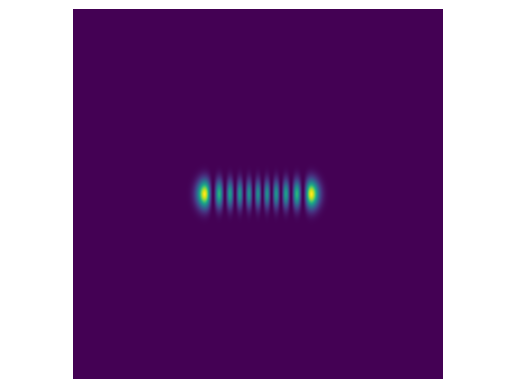

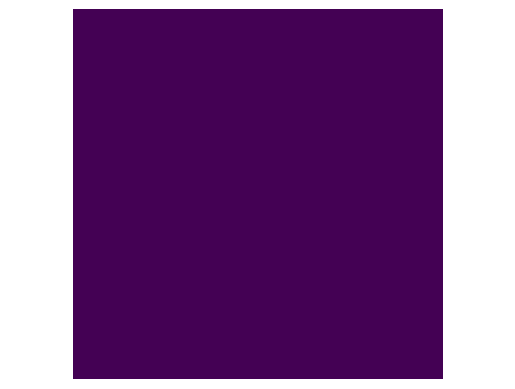

In [ ]:
I(out1)
I(out2)

# Deslocamento externo
##### além do deslocamento tem uma diferença de caminho devido ao bs

0.49999999999995276 0.49999999999995276
0.0
signal: 0.9999999999999055


(<Figure size 640x480 with 1 Axes>, <Axes: >)

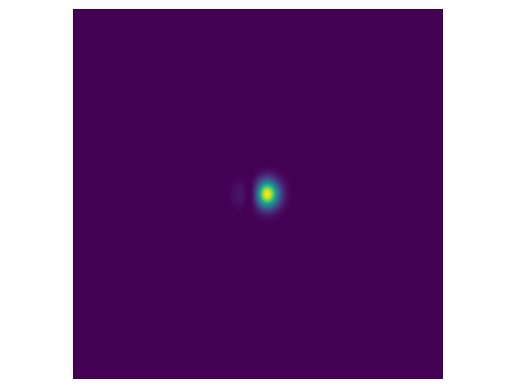

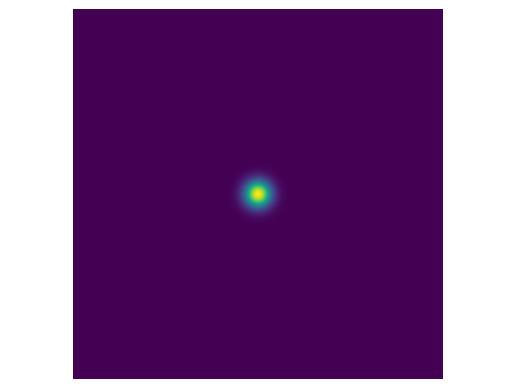

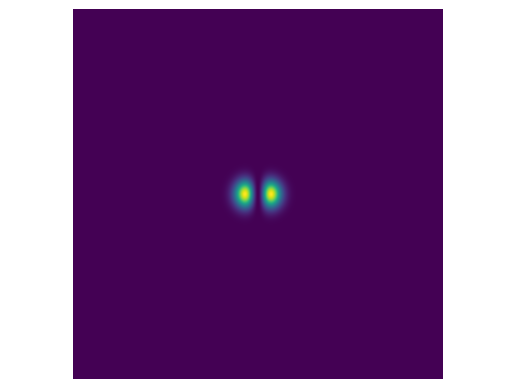

In [4]:
dx = 1e-2
z1 =.2
f = z1/2

m=0
hg = 1/np.sqrt(2)*(Hg(x, y, m) + Hg(x, y, m+1))
I(hg)
arm1,arm2 = bs(hg)
arm2 = -arm2
#arm2 = np.roll(arm2,1) # d = 20um de deslocamento; d/w = 2e-5/1e-3 = 0.02 << 1

arm1 = angSpec(arm1, x, y, z=f)
arm1 = lens(arm1, x, y, f=f)
arm1 = angSpec(arm1, x, y, z=f)
arm1 = mirror(arm1)
arm1 = angSpec(arm1, x, y, z=f)
arm1 = lens(arm1, x, y, f=f)
arm1 = angSpec(arm1, x, y, z=f)

out1,out2 = bs(arm1,arm2)
pw1 = pwr(x,y,out1)
pw2 = pwr(x,y,out2)

print(pw1, pw2)
print(pw1 - pw2)
print('signal:', pw1 + pw2 - np.abs(pw1 - pw2))

I(out1)
I(out2)

In [ ]:
deltax = 4e-2/2000
signal =[]
for dx in np.linspace(0,1e-2,10):
    #dx = 1e-2
    z1 =.2

    m=1
    hg = 1/np.sqrt(2)*(Hg(x + dx, y, m) + Hg(x - dx, y, m))

    arm1,arm2 = bs(hg,None)

    arm2 = np.roll(arm2,1) # d = 20um de deslocamento; d/w = 2e-5/1e-3 = 0.02 << 1 

    arm1 = angSpec(arm1, x, y, z=z1/2)
    #arm1 = lens(arm1, x, y, f=z1/2)
    arm1 = angSpec(arm1, x, y, z=z1/2)
    arm1 = mirror(arm1)
    arm1 = angSpec(arm1, x, y, z=z1/2)
    #arm1 = lens(arm1, x, y, f=z1/2)
    arm1 = angSpec(arm1, x, y, z=z1/2)

    out1,out2 = bs(arm1,arm2)
    pw1 = pwr(x,y,out1)
    pw2 = pwr(x,y,out2)

    print(pw1, pw2)
    print(pw1 - pw2)
    print('signal:', pw1 + pw2 - np.abs(pw1 - pw2))
    signal.append(pw1 + pw2 - np.abs(pw1 - pw2))

I(out1)
I(out2)

0.0024020010376432374 7.997597998963548
-7.995195997925905
signal: 0.00480400207528664


KeyboardInterrupt: 